# E-Commerce Sales Data Analysis

## Exploratory Data Analysis using Python

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Objective

The objective of this project is to analyze e-commerce transaction data,
clean the dataset, identify sales patterns, understand customer and product
performance, and generate business insights using Python.

## 1. Project Overview

This project performs exploratory data analysis on an e-commerce transaction
dataset.

The analysis focuses on:

- Overall sales performance
- Monthly sales trends
- Sales by country
- Top-performing products
- Customer sales contribution
- Return and cancellation analysis
- Sales by day of the week

In [1]:
pip install pandas numpy matplotlib seaborn

In [3]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import matplotlib for creating visualizations
import matplotlib.pyplot as plt

# Import seaborn for advanced and attractive visualizations
import seaborn as sns

In [5]:
# Load the raw e-commerce dataset
# encoding="latin1" allows Pandas to correctly read special characters
# such as the British pound (£) used in the dataset

df = pd.read_csv(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\01_Raw_Data\OnlineRetail.csv",
    encoding="latin1"
)

In [6]:
# Display the first 5 rows to confirm that the dataset loaded successfully

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


# Initial Data Understanding

In [7]:
# Check the number of rows and columns in the dataset
# This tells us how large our dataset is

df.shape

(541909, 8)

In [8]:
# Display all column names in the dataset
# This helps us understand what information is available

df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
# Display information about each column
# This shows data types, number of non-null values, and memory usage

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
# Count missing values in every column
# Missing values need to be handled during the cleaning stage

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# Count completely duplicated rows
# Duplicate records can affect our sales calculations

df.duplicated().sum()

5268

In [12]:
# Generate descriptive statistics for numerical columns
# This helps us understand the distribution of quantity and price

df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [13]:
# Count the number of unique values in every column
# This helps us understand which columns are identifiers,
# categories, or numerical measures

df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [14]:
# Generate statistics specifically for Quantity
# We are checking for unusual or negative quantities

df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [15]:
# Generate statistics for UnitPrice
# This helps identify zero, negative, or unusually high prices

df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [16]:
# Display the number of unique countries
# This helps us understand the geographical coverage of the dataset

df["Country"].nunique()

38

In [17]:
# Display all country names
df["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

# Data Cleaning

In [18]:
# Create a copy of the raw dataset
# We do this so the original raw data remains unchanged

df_clean = df.copy()

# Display the number of rows and columns
df_clean.shape

(541909, 8)

In [19]:
# Check the number of duplicate rows before removing them
duplicates = df_clean.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 5268


In [20]:
# Remove completely duplicated rows
# keep="first" keeps the first occurrence and removes repeated copies

df_clean = df_clean.drop_duplicates()

# Check the new number of rows
df_clean.shape

(536641, 8)

In [21]:
# Check missing values after removing duplicates

df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

In [22]:
# Convert InvoiceDate from text/object format to datetime
# This allows us to perform time-based analysis later

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Check the data type
df_clean["InvoiceDate"].dtype

dtype('<M8[ns]')

In [23]:
# Count records where Quantity is zero or negative
# Negative quantities can represent returned/cancelled items

(df_clean["Quantity"] <= 0).sum()

10587

In [24]:
# Count records where UnitPrice is zero or negative
# A negative price is generally invalid for sales analysis

(df_clean["UnitPrice"] <= 0).sum()

2512

In [25]:
# Remove transactions where UnitPrice is zero or negative
# These records cannot contribute meaningful positive sales revenue

df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Check the number of remaining rows
df_clean.shape

(534129, 8)

In [26]:
# Calculate sales/revenue for each transaction
# Sales = Quantity × Unit Price

df_clean["Sales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Display the first 5 calculated sales values
df_clean[["Quantity", "UnitPrice", "Sales"]].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [27]:
# Display the first 5 rows of the cleaned dataset
# This helps us confirm that our cleaning steps worked

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [28]:
# Check the final data types, non-null values, and memory usage

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 534129 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    534129 non-null  object        
 1   StockCode    534129 non-null  object        
 2   Description  534129 non-null  object        
 3   Quantity     534129 non-null  int64         
 4   InvoiceDate  534129 non-null  datetime64[ns]
 5   UnitPrice    534129 non-null  float64       
 6   CustomerID   401564 non-null  float64       
 7   Country      534129 non-null  object        
 8   Sales        534129 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.8+ MB


In [29]:
# Check for remaining duplicate rows

df_clean.duplicated().sum()

0

In [30]:
# Check for remaining invalid prices

(df_clean["UnitPrice"] <= 0).sum()

0

In [31]:
# Check how many records have zero or negative quantities
# Negative quantities may represent returned/cancelled items
# We are only checking them for now, not deleting them

(df_clean["Quantity"] <= 0).sum()

9251

In [32]:
# Check how many records have zero or negative unit prices
# A valid sales transaction should normally have a positive unit price

(df_clean["UnitPrice"] <= 0).sum()

0

In [33]:
# Calculate sales/revenue for each transaction
# Sales = Quantity × UnitPrice
# This new column will be used for our sales analysis

df_clean["Sales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Display the first 5 rows to verify the calculation
df_clean[["Quantity", "UnitPrice", "Sales"]].head()

,Quantity,UnitPrice,Sales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [34]:
# Check the data type of every column
# This confirms that InvoiceDate is now a datetime column
# and that numerical columns have appropriate data types

df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
Sales                 float64
dtype: object

In [35]:
# Save the cleaned dataset as a CSV file
# ../ moves from 02_Python back to the main project folder
# Then we enter the 03_Cleaned_Data folder

df_clean.to_csv(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\03_Cleaned_Data\ECommerce_Sales_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [36]:
# Load the saved cleaned CSV again
# This confirms that the file was saved correctly

df_check = pd.read_csv(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\03_Cleaned_Data\ECommerce_Sales_Cleaned.csv",
    encoding="latin1"
)

# Display the first 5 rows
df_check.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [37]:
# Check the number of rows and columns in the saved cleaned dataset

df_check.shape

(534129, 9)

In [38]:
df_clean.shape

(534129, 9)

# Exploratory Data Analysis

In [39]:
# Calculate the total sales/revenue generated
# This gives us the overall revenue across all transactions

total_sales = df_clean["Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 9748131.074


In [40]:
# Calculate the total quantity of products sold
# This tells us the overall sales volume

total_quantity = df_clean["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5296860


In [41]:
'''High revenue + low quantity

could mean expensive products.

Low revenue + high quantity

could mean low-priced products.'''

'High revenue + low quantity\n\ncould mean expensive products.\n\nLow revenue + high quantity\n\ncould mean low-priced products.'

In [43]:
# Count the number of unique invoices/orders
# Each InvoiceNo represents a transaction/order
#We're using nunique() rather than count() because the same invoice can contain multiple product lines.

total_orders = df_clean["InvoiceNo"].nunique()

print("Total Orders:", total_orders)

Total Orders: 23796


In [44]:
# Count the number of unique products
# StockCode is used as the product identifier
# This tells us how many different products are represented in the dataset.
total_products = df_clean["StockCode"].nunique()

print("Total Unique Products:", total_products)

Total Unique Products: 3938


In [45]:
# Count unique customers
# dropna() excludes transactions where CustomerID is missing
# This helps us understand the size of the customer base.
# We're excluding missing CustomerID values because we cannot identify those customers.

total_customers = df_clean["CustomerID"].dropna().nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 4371


In [46]:
# Calculate Average Order Value (AOV)
# AOV = Total Sales / Number of Orders
# On average, how much revenue does each order generate?

average_order_value = total_sales / total_orders

print("Average Order Value:", average_order_value)

Average Order Value: 409.65418868717427


In [47]:
# Create a summary of the main business KPIs
# This gives us a quick overview of the dataset

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Quantity Sold",
        "Total Orders",
        "Unique Products",
        "Unique Customers",
        "Average Order Value"
    ],
    
    "Value": [
        total_sales,
        total_quantity,
        total_orders,
        total_products,
        total_customers,
        average_order_value
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,9.748131e+06
1,Total Quantity Sold,5.296860e+06
2,Total Orders,2.379600e+04
3,Unique Products,3.938000e+03
4,Unique Customers,4.371000e+03
5,Average Order Value,4.096542e+02


In [48]:
# Format the monetary values for easier reading
# This does not change the underlying data

print(f"Total Sales: £{total_sales:,.2f}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Sales: £9,748,131.07
Average Order Value: £409.65


# Monthly Sales Analysis
How does sales revenue change month by month?

In [49]:
# Extract the year and month from InvoiceDate
# This allows us to group sales by month

df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

# Display the first 5 YearMonth values
df_clean["YearMonth"].head()

0    2010-01
1    2010-01
2    2010-01
3    2010-01
4    2010-01
Name: YearMonth, dtype: period[M]

In [51]:
# Calculate Monthly Sales
# Group the data by YearMonth
# Sum Sales for each month to calculate monthly revenue

monthly_sales = (
    df_clean.groupby("YearMonth")["Sales"]
    .sum()
    .reset_index()
)

# Display the monthly sales table
monthly_sales

,YearMonth,Sales
0,2010-01,58451.560
1,2010-02,46088.320
2,2010-03,45575.380
3,2010-05,30973.630
4,2010-06,53653.870
5,2010-07,44994.700
6,2010-08,44035.220
7,2010-09,52494.140
8,2010-10,57303.010
9,2010-12,313153.780


In [52]:
# Find the Highest-Sales Month
# Find the month with the highest sales
#This helps us answer: Which month generated the highest revenue?

highest_sales_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]

highest_sales_month

YearMonth      2011-11
Sales        1295691.6
Name: 20, dtype: object

In [54]:
# Find the Lowest-Sales Month
# Find the month with the lowest sales
# This gives us another business insight: Which month generated the lowest revenue?
lowest_sales_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmin()
]

lowest_sales_month

YearMonth     2010-05
Sales        30973.63
Name: 3, dtype: object

In [55]:
monthly_sales

,YearMonth,Sales
0,2010-01,58451.560
1,2010-02,46088.320
2,2010-03,45575.380
3,2010-05,30973.630
4,2010-06,53653.870
5,2010-07,44994.700
6,2010-08,44035.220
7,2010-09,52494.140
8,2010-10,57303.010
9,2010-12,313153.780


# Monthly Sales Trend

In [56]:
# Convert YearMonth from Period format to a string
# This makes the values easier to use as chart labels
# We'll convert it to text so Matplotlib can display it properly on the x-axis.
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

# Display the updated table
monthly_sales.head()

,YearMonth,Sales
0,2010-01,58451.56
1,2010-02,46088.32
2,2010-03,45575.38
3,2010-05,30973.63
4,2010-06,53653.87


# Monthly Sales Chart

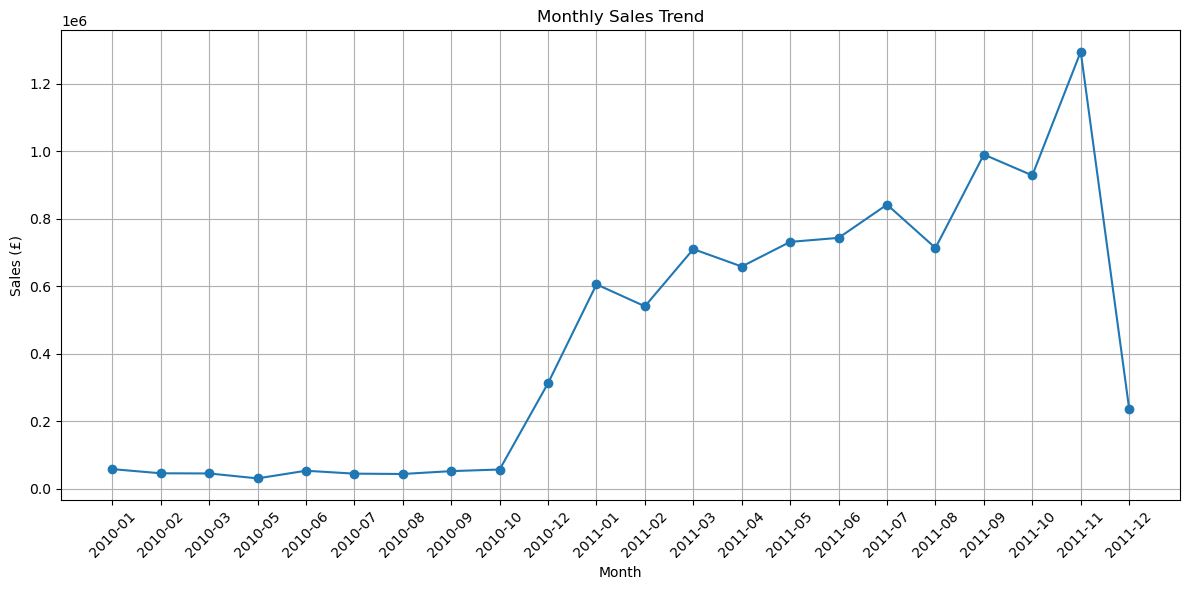

In [58]:
# Save the monthly sales chart as a PNG image
# This image can later be used in our GitHub project and README

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save the chart inside the 04_Visuals folder
plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sales by Country
Which countries generate the most sales?

This is useful because it tells us where the business has the strongest revenue contribution.

In [59]:
# Group the data by Country
# Sum the Sales column to calculate total revenue generated by each country
# We're grouping all transactions by country and adding their sales.

country_sales = (
    df_clean.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display the top 10 countries by sales
country_sales.head(10)

,Country,Sales
0,United Kingdom,8189252.304
1,Netherlands,284661.540
2,EIRE,262993.380
3,Germany,221509.470
4,France,197317.110
5,Australia,137009.770
6,Switzerland,56363.050
7,Spain,54756.030
8,Belgium,40910.960
9,Sweden,36585.410


In [60]:
# Select the 10 countries with the highest sales
# Instead of putting every country into a chart, we'll focus on the Top 10 so the visualization is easy to understand.
top_10_countries = country_sales.head(10)

top_10_countries

,Country,Sales
0,United Kingdom,8189252.304
1,Netherlands,284661.540
2,EIRE,262993.380
3,Germany,221509.470
4,France,197317.110
5,Australia,137009.770
6,Switzerland,56363.050
7,Spain,54756.030
8,Belgium,40910.960
9,Sweden,36585.410


In [61]:
# Identify the country with the highest total sales
# Which country generated the highest revenue?
top_country = country_sales.iloc[0]

print("Top Sales Country:", top_country["Country"])
print("Sales:", top_country["Sales"])

Top Sales Country: United Kingdom
Sales: 8189252.304


# Country Sales Chart

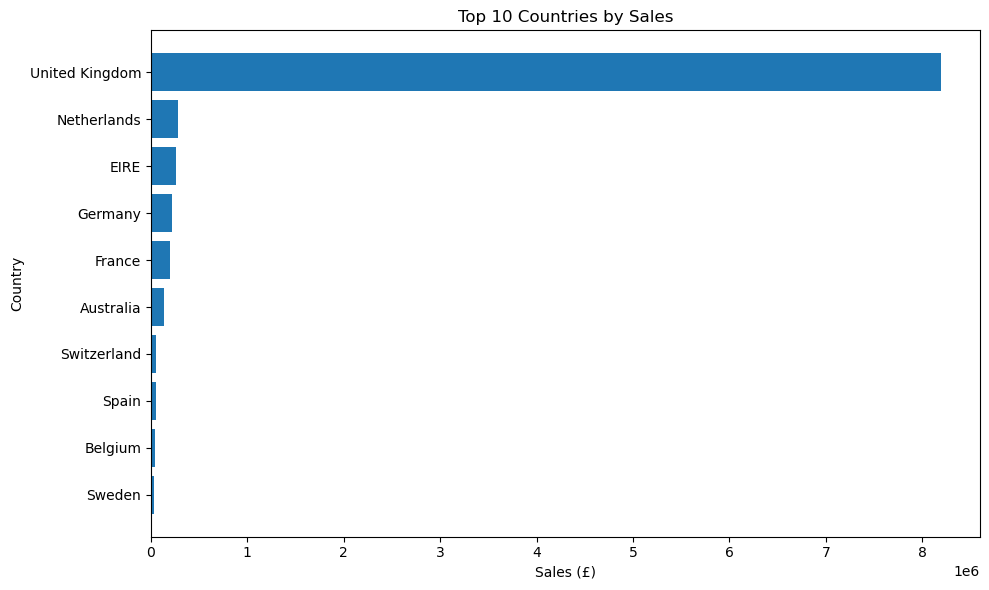

In [63]:
# Save the country sales chart as a PNG file
# This image will be included in our GitHub project

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_countries["Country"][::-1],
    top_10_countries["Sales"][::-1]
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales (£)")
plt.ylabel("Country")

plt.tight_layout()

# Save the visualization
plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\country_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Top 10 Products by Sales
Which products generate the highest sales?

This is useful because businesses can identify their strongest products and understand where revenue is concentrated.

In [64]:
# Group the data by StockCode (product ID)
# Sum Sales to calculate the total revenue generated by each product
# StockCode is the product identifier in this dataset.
# We use it instead of Description because descriptions can sometimes be missing or inconsistent.

product_sales = (
    df_clean.groupby("StockCode")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display the top 10 products by sales
product_sales.head(10)

,StockCode,Sales
0,DOT,206245.48
1,22423,164459.49
2,47566,98243.88
3,85123A,97838.45
4,85099B,92175.79
5,23084,66661.63
6,POST,66230.64
7,22086,63715.24
8,84879,58792.42
9,79321,53746.66


In [65]:
# Select the 10 products with the highest sales

top_10_products = product_sales.head(10)

top_10_products

,StockCode,Sales
0,DOT,206245.48
1,22423,164459.49
2,47566,98243.88
3,85123A,97838.45
4,85099B,92175.79
5,23084,66661.63
6,POST,66230.64
7,22086,63715.24
8,84879,58792.42
9,79321,53746.66


In [66]:
# Create a lookup table containing StockCode and Description
# drop_duplicates() ensures each StockCode appears only once

product_lookup = (
    df_clean[["StockCode", "Description"]]
    .drop_duplicates("StockCode")
)

# Add the product description to our top 10 products
top_10_products = top_10_products.merge(
    product_lookup,
    on="StockCode",
    how="left"
)

# Display the result
top_10_products

,StockCode,Sales,Description
0,DOT,206245.48,DOTCOM POSTAGE
1,22423,164459.49,REGENCY CAKESTAND 3 TIER
2,47566,98243.88,PARTY BUNTING
3,85123A,97838.45,WHITE HANGING HEART T-LIGHT HOLDER
4,85099B,92175.79,JUMBO BAG RED RETROSPOT
5,23084,66661.63,RABBIT NIGHT LIGHT
6,POST,66230.64,POSTAGE
7,22086,63715.24,PAPER CHAIN KIT 50'S CHRISTMAS
8,84879,58792.42,ASSORTED COLOUR BIRD ORNAMENT
9,79321,53746.66,CHILLI LIGHTS


# Top Products Chart

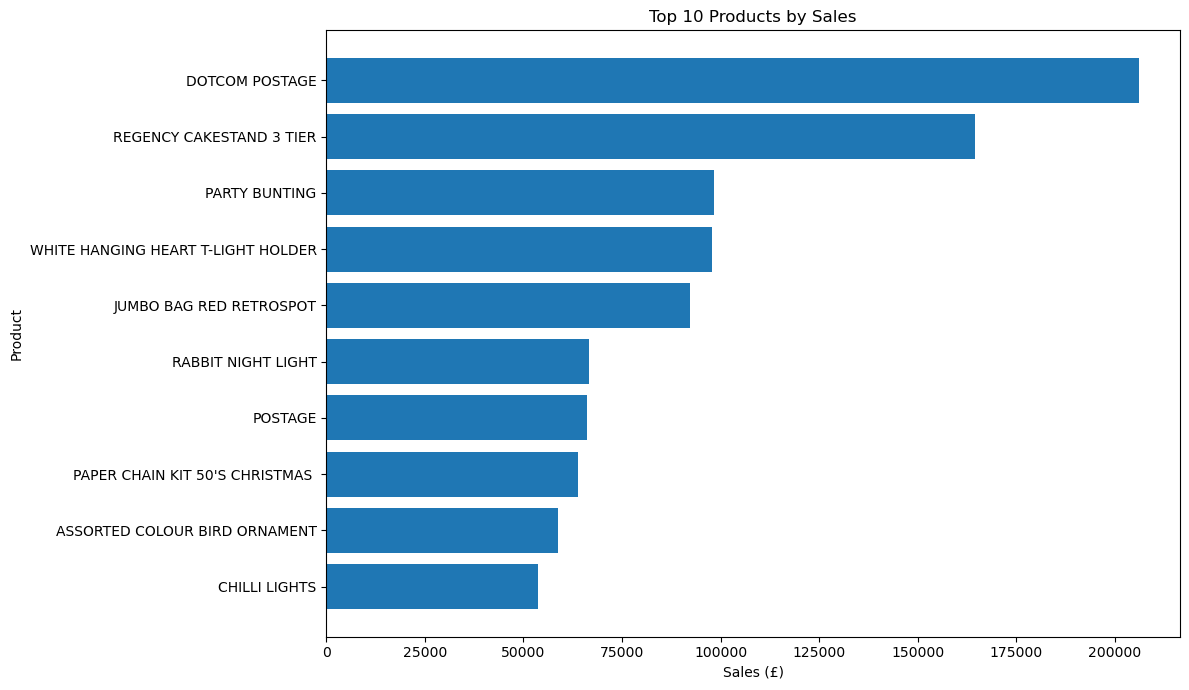

In [67]:
# Save the top products chart as a PNG file
# This image will be included in our GitHub project

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_products["Description"][::-1],
    top_10_products["Sales"][::-1]
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales (£)")
plt.ylabel("Product")

plt.tight_layout()

# Save the chart
plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\top_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer Analysis

In [69]:
'''Some transactions don't have a CustomerID.

We cannot identify those customers, so we exclude them only from customer-level analysis.

We are not deleting them from df_clean.'''

# Create a separate dataset containing only records
# where CustomerID is available

customer_df = df_clean.dropna(subset=["CustomerID"]).copy()

# Check the number of records available for customer analysis
customer_df.shape

(401564, 10)

In [70]:
# Group transactions by CustomerID
# Sum Sales to calculate the total revenue generated by each customer
# Sales by Customer
customer_sales = (
    customer_df.groupby("CustomerID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Display the top 10 customers by sales
customer_sales.head(10)

,CustomerID,Sales
0,14646.0,279489.02
1,18102.0,256438.49
2,17450.0,187322.17
3,14911.0,132458.73
4,12415.0,123725.45
5,14156.0,113214.59
6,17511.0,88125.38
7,16684.0,65892.08
8,13694.0,62690.54
9,15311.0,59284.19


In [71]:
# Select the top 10 customers by total sales

top_10_customers = customer_sales.head(10)

top_10_customers

,CustomerID,Sales
0,14646.0,279489.02
1,18102.0,256438.49
2,17450.0,187322.17
3,14911.0,132458.73
4,12415.0,123725.45
5,14156.0,113214.59
6,17511.0,88125.38
7,16684.0,65892.08
8,13694.0,62690.54
9,15311.0,59284.19


# Customer Sales Chart

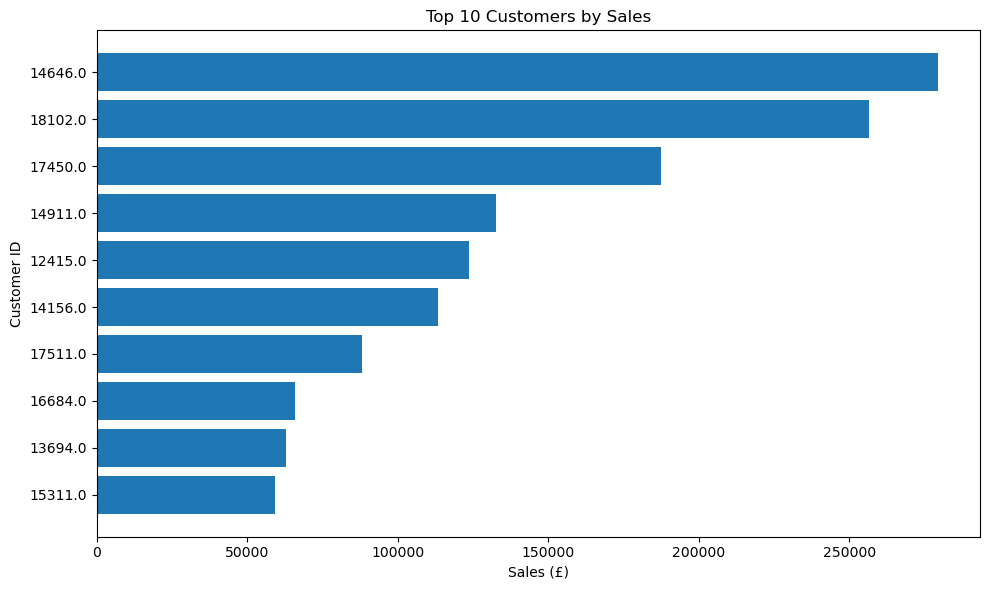

In [72]:
# Save the customer sales visualization
# This image will be used in our GitHub project

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_customers["CustomerID"].astype(str)[::-1],
    top_10_customers["Sales"][::-1]
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\top_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Orders per Customer
A customer who generates high sales isn't necessarily the customer who orders most frequently.

This lets us compare:
Revenue contribution
Order frequency

In [73]:
# Count the number of unique orders placed by each customer

customer_orders = (
    customer_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Order_Count")
)

# Display the top 10 customers by number of orders
customer_orders.head(10)

,CustomerID,Order_Count
0,14911.0,248
1,12748.0,223
2,17841.0,169
3,14606.0,128
4,13089.0,118
5,15311.0,118
6,12971.0,89
7,14527.0,86
8,13408.0,81
9,14646.0,76


# Average Sales per Customer

In [74]:
# Calculate the average revenue generated per identified customer

average_customer_sales = customer_sales["Sales"].mean()

print(f"Average Sales per Customer: £{average_customer_sales:,.2f}")

Average Sales per Customer: £1,893.96


# Returns / Cancellation Analysis

In [76]:
# Count Return Transactions
# Identify transactions with negative or zero quantity
# These transactions may represent returns or cancellations
# We want to know how many transaction lines appear to represent returns/cancellations.
return_df = df_clean[df_clean["Quantity"] <= 0].copy()

# Count the number of return/cancellation records
return_transactions = len(return_df)

print("Return/Cancellation Transactions:", return_transactions)

Return/Cancellation Transactions: 9251


In [78]:
# Calculate the total quantity associated with returns/cancellations
# We use absolute value so the result represents the number of items returned
# Calculate Return Quantity
# Negative quantities represent items coming back to the business.
total_return_quantity = abs(return_df["Quantity"].sum())

print("Total Items Returned:", total_return_quantity)

Total Items Returned: 275560


In [79]:
# Calculate Return Value
# This tells us approximately how much sales value is associated with the return transactions.
# Calculate the monetary value associated with return transactions
# Sales is negative when Quantity is negative,
# so we use the absolute value for reporting

return_value = abs(return_df["Sales"].sum())

print(f"Return Value: £{return_value:,.2f}")

Return Value: £893,979.73


In [81]:
# Calculate Return Rate
# This gives us a percentage that is easier to communicate.
# Calculate the percentage of transaction lines
# that have zero or negative quantities

return_rate = (len(return_df) / len(df_clean)) * 100

print(f"Return/Cancellation Transaction Rate: {return_rate:.2f}%")

'''' Important: We should call this a transaction-line return/cancellation rate, 
not a true customer return rate, because the dataset doesn't explicitly identify the reason for every negative quantity. '''

Return/Cancellation Transaction Rate: 1.73%


"' Important: We should call this a transaction-line return/cancellation rate, \nnot a true customer return rate, because the dataset doesn't explicitly identify the reason for every negative quantity. "

In [82]:
# Check Invoice Numbers
# Let's investigate whether these records have special invoice numbers.
# Display a sample of InvoiceNo values from return/cancellation records
# This helps us investigate how these transactions are represented

return_df["InvoiceNo"].head(20)

141     C536379
154     C536383
235     C536391
236     C536391
237     C536391
238     C536391
239     C536391
240     C536391
241     C536391
939     C536506
1441    C536543
1442    C536543
1973    C536548
1974    C536548
1975    C536548
1976    C536548
1977    C536548
1978    C536548
1979    C536548
1980    C536548
Name: InvoiceNo, dtype: object

In [83]:
# Check Invoices Starting With "C"
'''In this dataset, cancelled invoices are commonly represented with a C prefix.
This helps us distinguish C-prefixed cancelled invoices from other negative-quantity records.

We're investigating the data rather than making assumptions.
'''
# Check how many return/cancellation records have InvoiceNo
# values beginning with the letter C

cancelled_invoice_count = return_df["InvoiceNo"].astype(str).str.startswith("C").sum()

print("Transactions with C-prefixed InvoiceNo:", cancelled_invoice_count)

Transactions with C-prefixed InvoiceNo: 9251


In [84]:
# Calculate Cancellation Rate
# This gives us a separate metric specifically for transactions marked with a C invoice prefix.
# Calculate the percentage of all transaction lines
# that have an invoice number beginning with C

cancelled_rate = (
    df_clean["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
    .mean() * 100
)

print(f"Cancellation Transaction-Line Rate: {cancelled_rate:.2f}%")


Cancellation Transaction-Line Rate: 1.73%


# Sales by Day of Week

In [86]:
# Extract the day of the week from InvoiceDate
# This allows us to compare sales across different weekdays
# This allows us to identify patterns in customer purchasing behavior.

df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()

# Display the first 5 values
df_clean["DayOfWeek"].head()

0    Tuesday
1    Tuesday
2    Tuesday
3    Tuesday
4    Tuesday
Name: DayOfWeek, dtype: object

In [87]:
# Group sales by day of the week
# Sum Sales to calculate total revenue for each day

day_sales = (
    df_clean.groupby("DayOfWeek")["Sales"]
    .sum()
    .reset_index()
)

# Display the result
day_sales

,DayOfWeek,Sales
0,Friday,1482808.341
1,Monday,1484801.341
2,Saturday,543551.480
3,Sunday,1048421.781
4,Thursday,1792657.200
5,Tuesday,1980739.271
6,Wednesday,1415151.660


In [88]:
# Define the correct order of the days

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Convert DayOfWeek into an ordered categorical column

day_sales["DayOfWeek"] = pd.Categorical(
    day_sales["DayOfWeek"],
    categories=day_order,
    ordered=True
)

# Sort according to the correct day order

day_sales = day_sales.sort_values("DayOfWeek")

day_sales

,DayOfWeek,Sales
1,Monday,1484801.341
5,Tuesday,1980739.271
6,Wednesday,1415151.660
4,Thursday,1792657.200
0,Friday,1482808.341
2,Saturday,543551.480
3,Sunday,1048421.781


In [89]:
# Find the day with the highest total sales

highest_sales_day = day_sales.loc[
    day_sales["Sales"].idxmax()
]

highest_sales_day

DayOfWeek        Tuesday
Sales        1980739.271
Name: 5, dtype: object

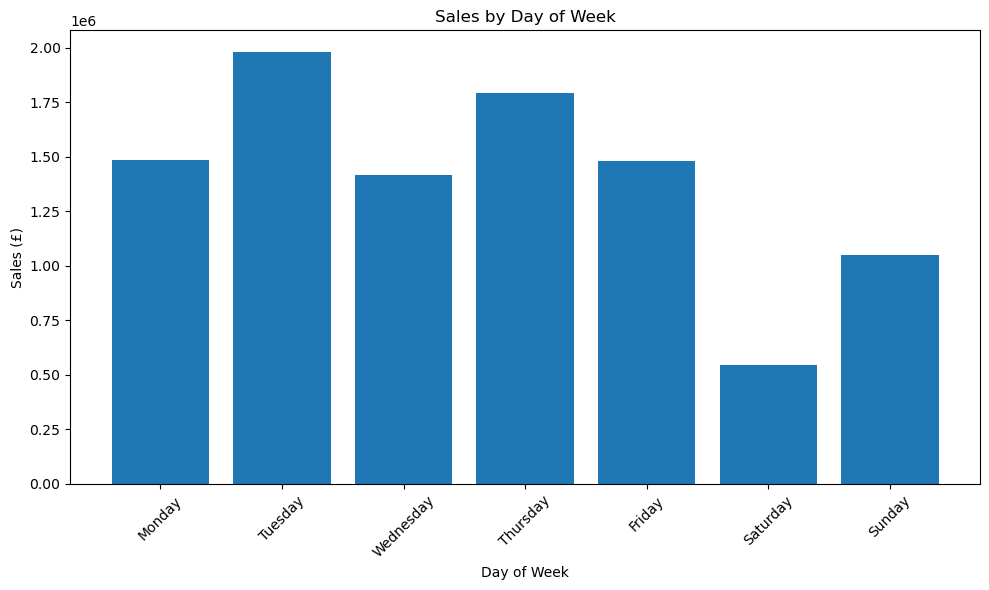

In [90]:
# Save the day-of-week sales chart
# This visualization will be included in the GitHub project

plt.figure(figsize=(10, 6))

plt.bar(
    day_sales["DayOfWeek"],
    day_sales["Sales"]
)

plt.title("Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Sales (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\day_of_week_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Cancellation / Order Status Analysis
We already found that some InvoiceNo values start with C. Now we'll quantify how many orders are cancelled and compare them with normal orders.

What proportion of orders are cancelled?

In [91]:
# Create a new column called OrderStatus
# If InvoiceNo starts with "C", classify it as Cancelled
# Otherwise classify it as Completed
#We're creating a business-friendly column from the raw InvoiceNo.

df_clean["OrderStatus"] = np.where(
    df_clean["InvoiceNo"].astype(str).str.startswith("C"),
    "Cancelled",
    "Completed"
)

# Display the first 10 order statuses
df_clean[["InvoiceNo", "OrderStatus"]].head(10)

,InvoiceNo,OrderStatus
0,536365,Completed
1,536365,Completed
2,536365,Completed
3,536365,Completed
4,536365,Completed
5,536365,Completed
6,536365,Completed
7,536366,Completed
8,536366,Completed
9,536367,Completed


In [92]:
# Count the number of transaction lines for each order status
#This tells us how many transaction lines are: Completed,Cancelled
order_status_count = (
    df_clean["OrderStatus"]
    .value_counts()
    .reset_index()
)

# Rename the columns for readability

order_status_count.columns = [
    "OrderStatus",
    "Transaction_Count"
]

order_status_count

,OrderStatus,Transaction_Count
0,Completed,524878
1,Cancelled,9251


In [93]:
# Calculate the percentage of transaction lines for each order status
# Raw counts are useful, but percentages are easier to communicate.
order_status_count["Percentage"] = (
    order_status_count["Transaction_Count"]
    / order_status_count["Transaction_Count"].sum()
    * 100
)

order_status_count

,OrderStatus,Transaction_Count,Percentage
0,Completed,524878,98.268021
1,Cancelled,9251,1.731979


# Cancellation Chart

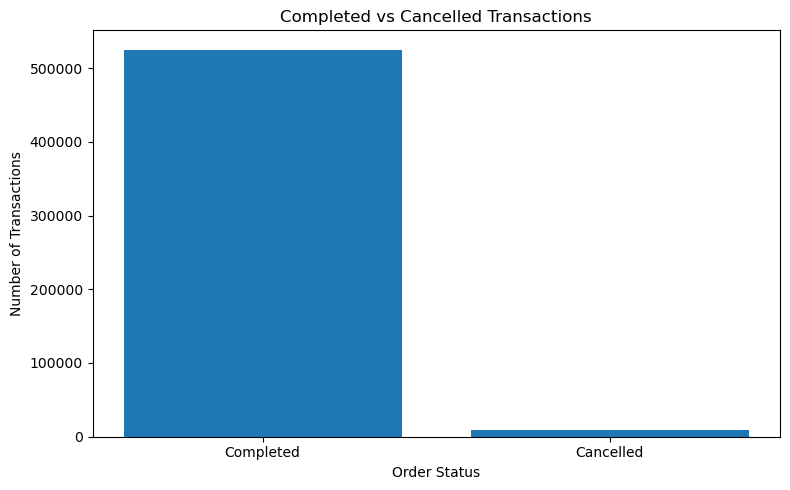

In [94]:
# Save the order status chart
# This visualization will be included in the GitHub project

plt.figure(figsize=(8, 5))

plt.bar(
    order_status_count["OrderStatus"],
    order_status_count["Transaction_Count"]
)

plt.title("Completed vs Cancelled Transactions")
plt.xlabel("Order Status")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig(
    r"C:\Users\vgova\Downloads\data_analytics-\Projects\E-Commerce-Sales-EDA\04_Visuals\order_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# One important correction

We shouldn't call every negative quantity a cancellation.

That's why we are using the InvoiceNo prefix:

InvoiceNo starts with C → Cancelled

while:

Quantity <= 0

is our broader return/non-positive quantity indicator.

This distinction will make your interview explanation more accurate.

# Final Business Insights

In [95]:
# Find the month with the highest sales

best_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]

print("Highest Sales Month:", best_month["YearMonth"])
print(f"Sales: £{best_month['Sales']:,.2f}")

Highest Sales Month: 2011-11
Sales: £1,295,691.60


In [96]:
# Find the country with the highest sales

best_country = country_sales.iloc[0]

print("Top Country:", best_country["Country"])
print(f"Sales: £{best_country['Sales']:,.2f}")

Top Country: United Kingdom
Sales: £8,189,252.30


In [97]:
# Find the product with the highest sales

best_product = top_10_products.iloc[0]

print("Top Product:", best_product["Description"])
print(f"Sales: £{best_product['Sales']:,.2f}")

Top Product: DOTCOM POSTAGE
Sales: £206,245.48


In [98]:
# Find the day of the week with the highest sales

best_day = day_sales.loc[
    day_sales["Sales"].idxmax()
]

print("Highest Sales Day:", best_day["DayOfWeek"])
print(f"Sales: £{best_day['Sales']:,.2f}")

Highest Sales Day: Tuesday
Sales: £1,980,739.27


In [99]:
# Find the customer who generated the highest total sales

best_customer = top_10_customers.iloc[0]

print("Top Customer ID:", best_customer["CustomerID"])
print(f"Sales: £{best_customer['Sales']:,.2f}")

Top Customer ID: 14646.0
Sales: £279,489.02


In [100]:
# Get the cancellation transaction-line rate
# from our previous analysis

print(f"Cancellation Rate: {cancelled_rate:.2f}%")

Cancellation Rate: 1.73%


In [101]:
# Create a summary table of the key business insights
# This table will help us later when creating the README
# and preparing for interviews
# This gives us one place containing the key findings.
final_insights = pd.DataFrame({
    "Insight": [
        "Total Sales",
        "Total Orders",
        "Average Order Value",
        "Unique Customers",
        "Unique Products",
        "Highest Sales Month",
        "Top Sales Country",
        "Top Product",
        "Highest Sales Day",
        "Cancellation Rate"
    ],
    
    "Value": [
        f"£{total_sales:,.2f}",
        f"{total_orders:,}",
        f"£{average_order_value:,.2f}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"{best_month['YearMonth']} (£{best_month['Sales']:,.2f})",
        f"{best_country['Country']} (£{best_country['Sales']:,.2f})",
        f"{best_product['Description']} (£{best_product['Sales']:,.2f})",
        f"{best_day['DayOfWeek']} (£{best_day['Sales']:,.2f})",
        f"{cancelled_rate:.2f}%"
    ]
})

final_insights

,Insight,Value
0,Total Sales,"£9,748,131.07"
1,Total Orders,"23,796"
2,Average Order Value,£409.65
3,Unique Customers,"4,371"
4,Unique Products,"3,938"
5,Highest Sales Month,"2011-11 (£1,295,691.60)"
6,Top Sales Country,"United Kingdom (£8,189,252.30)"
7,Top Product,"DOTCOM POSTAGE (£206,245.48)"
8,Highest Sales Day,"Tuesday (£1,980,739.27)"
9,Cancellation Rate,1.73%


In [102]:
# Print the main business findings in a readable format
# These statements can later be adapted for our README and interview explanation

print("KEY BUSINESS INSIGHTS")
print("-" * 50)

print(
    f"1. The dataset generated total sales of £{total_sales:,.2f} "
    f"across {total_orders:,} orders."
)

print(
    f"2. The average order value was £{average_order_value:,.2f}."
)

print(
    f"3. {best_month['YearMonth']} recorded the highest monthly sales "
    f"of £{best_month['Sales']:,.2f}."
)

print(
    f"4. {best_country['Country']} generated the highest sales "
    f"of £{best_country['Sales']:,.2f}."
)

print(
    f"5. The highest-selling product was "
    f"{best_product['Description']}."
)

print(
    f"6. {best_day['DayOfWeek']} recorded the highest sales "
    f"among the days of the week."
)

print(
    f"7. Cancelled transactions represented approximately "
    f"{cancelled_rate:.2f}% of transaction lines."
)

KEY BUSINESS INSIGHTS
--------------------------------------------------
1. The dataset generated total sales of £9,748,131.07 across 23,796 orders.
2. The average order value was £409.65.
3. 2011-11 recorded the highest monthly sales of £1,295,691.60.
4. United Kingdom generated the highest sales of £8,189,252.30.
5. The highest-selling product was DOTCOM POSTAGE.
6. Tuesday recorded the highest sales among the days of the week.
7. Cancelled transactions represented approximately 1.73% of transaction lines.
